In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import joblib

from sklearn.pipeline        import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics         import classification_report, roc_auc_score

from src.data_loader         import load_raw_data, basic_profiling
from src.feature_engineering import build_viralidad, build_features, get_feature_columns
from src.preprocessing       import build_preprocessor, split_data, save_preprocessor

# IMPORTACIONES ACTUALIZADAS
from src.modeling            import get_base_models, tune_hyperparameters, cross_validate_models, train_and_save
from src.evaluation          import (
    evaluate_on_test, plot_confusion_matrices, plot_roc_curves,
    plot_feature_importance, plot_cv_comparison, plot_metrics_heatmap, save_tuning_report
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
SAMPLE_SIZE  = 100_000
RAW_PATH     = '../data/raw/global_youtube_creator_data_large.csv'
FIGURES_DIR  = '../reports/figures'

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


In [2]:
import os, pickle
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(''))
while PROJECT_ROOT.name != 'Proyecto_Final_ML':
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
print('Working dir:', PROJECT_ROOT)

# Redefinir rutas como absolutas tras el cambio de directorio
FIGURES_DIR = str(PROJECT_ROOT / 'reports' / 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(str(PROJECT_ROOT / 'models'), exist_ok=True)
os.makedirs(str(PROJECT_ROOT / 'data' / 'processed'), exist_ok=True)

# Cargar df_raw desde Fase 2
with open(PROJECT_ROOT / 'data' / 'processed' / 'df_raw.pkl', 'rb') as f:
    df_raw = pickle.load(f)

print('df_raw cargado:', df_raw.shape)

Working dir: c:\Users\jerez\MachineLearningProjects\Final\Proyecto_Final_ML
df_raw cargado: (100000, 12)


---
# FASE 3 | PREPARACION DE LOS DATOS (Data Preparation)
---

## 3.1 Limpieza de datos

In [3]:
df = df_raw.copy()

# Eliminar duplicados
antes = len(df)
df = df.drop_duplicates()
print(f'Duplicados eliminados: {antes - len(df)}')

# Eliminar registros con views = 0 (no aportan informacion de engagement)
df = df[df['views'] > 0].reset_index(drop=True)
print(f'Registros con views=0 eliminados: {antes - len(df)}')
print(f'Dataset limpio: {len(df):,} registros')

Duplicados eliminados: 0
Registros con views=0 eliminados: 11
Dataset limpio: 99,989 registros


## 3.2 Construcción de la variable objetivo: VIRALIDAD

### Metodología:

La variable `viralidad` se construye en 4 pasos:

1. **Transformacion logaritmica** (`log1p`) de views, likes, comments, shares para reducir el sesgo de la distribucion de cola larga.
2. **Rango percentil** de cada metrica transformada: ubica cada video en una posicion relativa (0 = menor, 1 = mayor) dentro del conjunto de datos.
3. **Puntaje compuesto ponderado**:

$$\text{engagement\_score} = 0.30 \cdot r_{views} + 0.25 \cdot r_{likes} + 0.20 \cdot r_{comments} + 0.25 \cdot r_{shares}$$

   Los pesos reflejan que las vistas (alcance) y los shares (propagacion) son los principales indicadores de viralidad, seguidos de likes y comentarios.

4. **Clasificacion binaria**: videos con `engagement_score >= percentil 50` son etiquetados como **virales** (1); los demas como **no virales** (0).

In [4]:
df = build_viralidad(df, threshold_pct=50)

[INFO] Umbral engagement_score (p50): 0.5070
[INFO] Videos virales  : 49,995 (50.0%)
[INFO] Videos no virales: 49,994 (50.0%)


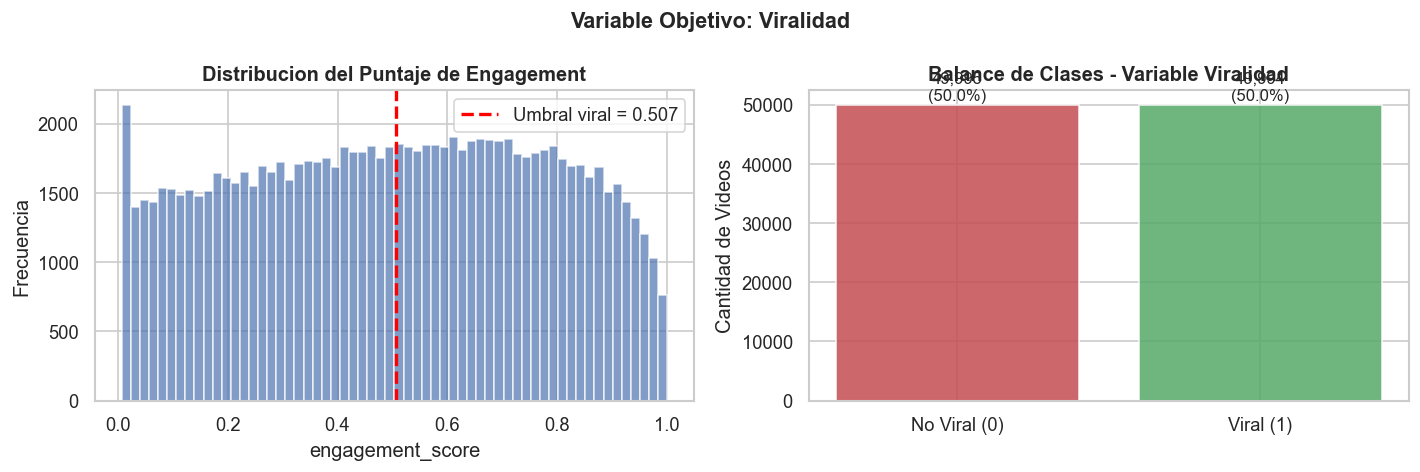

In [5]:
# Visualizar el puntaje de engagement y el corte de viralidad
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribucion del puntaje
umbral = df[df['viralidad'] == 1]['engagement_score'].min()
axes[0].hist(df['engagement_score'], bins=60, color='#4C72B0', alpha=0.7, edgecolor='white')
axes[0].axvline(umbral, color='red', linestyle='--', lw=2, label=f'Umbral viral = {umbral:.3f}')
axes[0].set_title('Distribucion del Puntaje de Engagement', fontweight='bold')
axes[0].set_xlabel('engagement_score')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Balance de clases
class_counts = df['viralidad'].value_counts()
labels = ['No Viral (0)', 'Viral (1)']
colors = ['#C44E52', '#55A868']
bars = axes[1].bar(labels, class_counts.values, color=colors, alpha=0.85)
for bar, val in zip(bars, class_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10)
axes[1].set_title('Balance de Clases - Variable Viralidad', fontweight='bold')
axes[1].set_ylabel('Cantidad de Videos')

plt.suptitle('Variable Objetivo: Viralidad', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/viralidad_distribucion.png', bbox_inches='tight')
plt.show()

## 3.3 Ingeniería de características

**Criterio de diseño:** Para evitar fuga de datos (*data leakage*), los modelos NO usan los valores brutos de views, likes, comments y shares (usados para construir `viralidad`). En su lugar se generan:

1. **Tasas de engagement relativo** (escala original): `likes_per_view`, `comments_per_view`, `shares_per_view`, `engagement_rate`.
2. **Versiones logarítmicas** de los ratios (`log_likes_per_view`, etc.): corrigen la asimetría severa detectada en el análisis de datos — videos con muy pocos views generan ratios extremos (ej. 50 likes / 1 view = 50). `log1p` comprime estos outliers sin alterar el orden relativo.
3. **Features temporales**: `hour`, `day_of_week`, `month` y el indicador binario `is_weekend` (derivado del análisis temporal de la Fase 2).

$$\text{likes\_per\_view} = \frac{\text{likes}}{\text{views}} \qquad \text{log\_likes\_per\_view} = \log(1 + \text{likes\_per\_view})$$

In [6]:
df = build_features(df)

feature_info = get_feature_columns()
print('Caracteristicas por tipo:')
for tipo, cols in feature_info.items():
    print(f'  {tipo:12}: {cols}')

Caracteristicas por tipo:
  categorical : ['category', 'language', 'region']
  numerical   : ['duration_sec', 'sentiment_score', 'likes_per_view', 'comments_per_view', 'shares_per_view', 'engagement_rate', 'log_likes_per_view', 'log_comments_per_view', 'log_shares_per_view', 'log_engagement_rate', 'sent_x_engagement', 'dur_x_log_engagement', 'hour', 'day_of_week', 'month']
  binary      : ['ads_enabled', 'is_weekend']


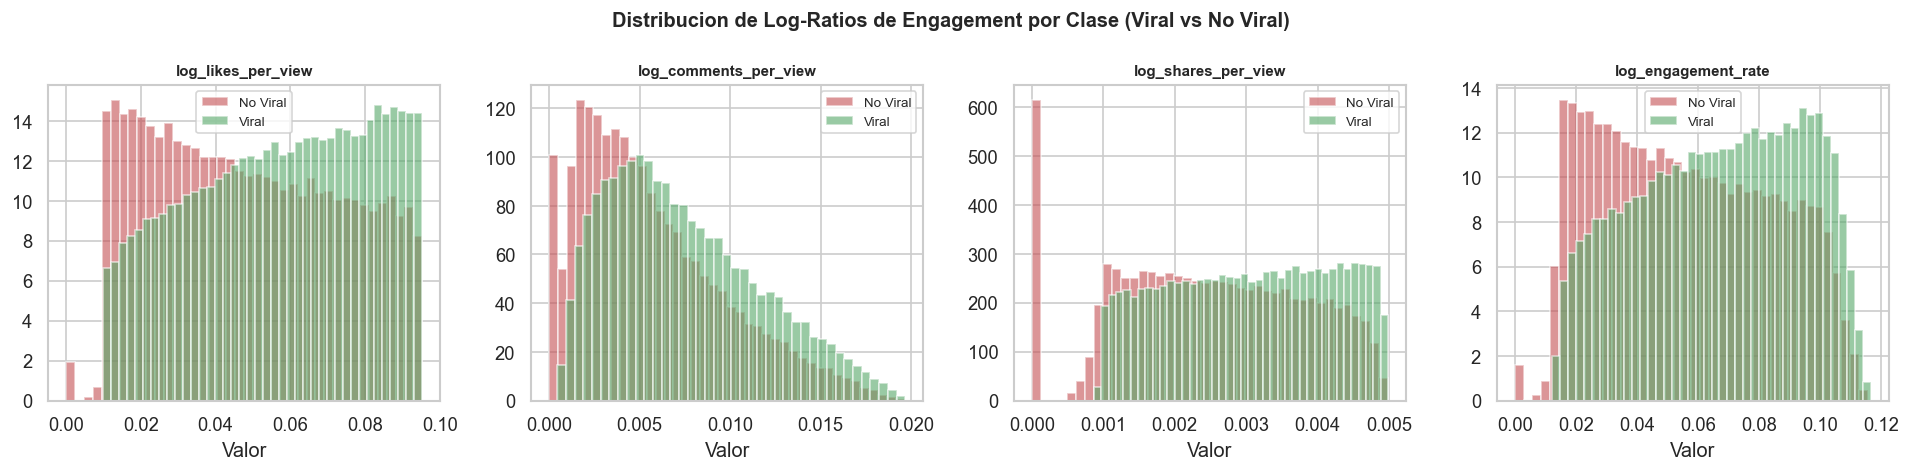

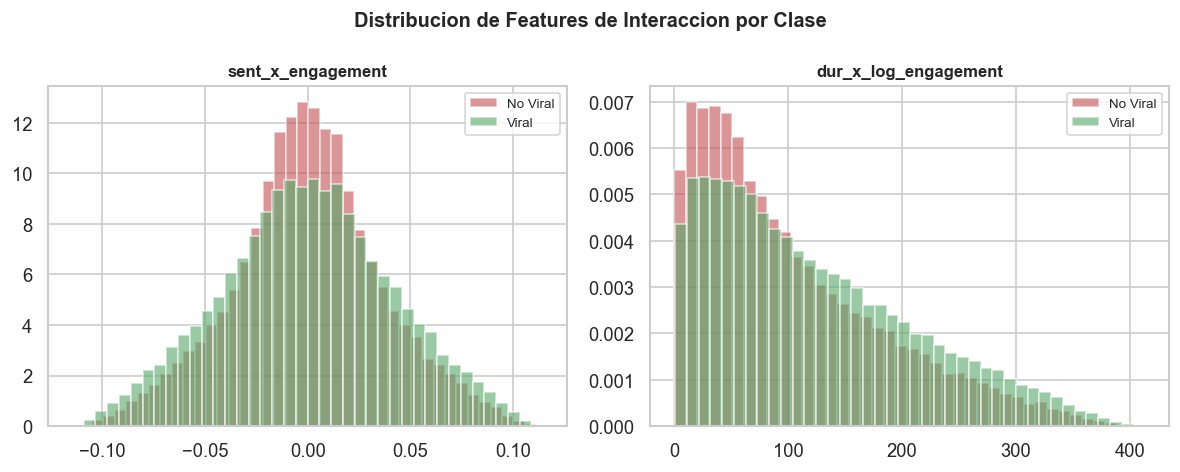

In [7]:
# Visualizar features de engagement (ratios log) por clase
rate_cols = ['log_likes_per_view', 'log_comments_per_view',
             'log_shares_per_view', 'log_engagement_rate']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, rate_cols):
    for label, color in [(0, '#C44E52'), (1, '#55A868')]:
        subset = df[df['viralidad'] == label][col]
        ax.hist(subset, bins=40, alpha=0.6, color=color,
                label='No Viral' if label == 0 else 'Viral', density=True)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.legend(fontsize=8)

plt.suptitle('Distribucion de Log-Ratios de Engagement por Clase (Viral vs No Viral)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/engagement_rates_por_clase.png', bbox_inches='tight')
plt.show()

# Visualizar features de interaccion
inter_cols = ['sent_x_engagement', 'dur_x_log_engagement']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, inter_cols):
    for label, color in [(0, '#C44E52'), (1, '#55A868')]:
        subset = df[df['viralidad'] == label][col]
        ax.hist(subset, bins=40, alpha=0.6, color=color,
                label='No Viral' if label == 0 else 'Viral', density=True)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Distribucion de Features de Interaccion por Clase',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/interacciones_por_clase.png', bbox_inches='tight')
plt.show()

## 3.4 Partición train / test y preprocesamiento

In [8]:
feature_info = get_feature_columns()
cat_cols = feature_info['categorical']
num_cols = feature_info['numerical']
bin_cols = feature_info['binary']
all_features = cat_cols + num_cols + bin_cols

X_train, X_test, y_train, y_test = split_data(
    df, feature_cols=all_features, target_col='viralidad',
    test_size=0.20, random_state=RANDOM_STATE
)

[INFO] Entrenamiento: 79,991 muestras | Prueba: 19,998 muestras
[INFO] Balance en train - Viral: 50.0% | No viral: 50.0%
[INFO] Balance en test  - Viral: 50.0% | No viral: 50.0%


In [9]:
# Construir y ajustar el preprocesador sobre los datos de entrenamiento
preprocessor = build_preprocessor(cat_cols, num_cols, bin_cols)
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

save_preprocessor(preprocessor, path=str(PROJECT_ROOT / 'models' / 'preprocessor.joblib'))

# Nombres de caracteristicas tras el preprocesamiento
ohe_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
feature_names_proc = ohe_names + num_cols + bin_cols

print(f'\nDimensiones post-preprocesamiento:')
print(f'  X_train: {X_train_proc.shape}')
print(f'  X_test : {X_test_proc.shape}')
print(f'  Total features: {len(feature_names_proc)}')

[INFO] Preprocesador guardado en: c:\Users\jerez\MachineLearningProjects\Final\Proyecto_Final_ML\models\preprocessor.joblib

Dimensiones post-preprocesamiento:
  X_train: (79991, 33)
  X_test : (19998, 33)
  Total features: 33


## 3.5 Target Encoding de Variables Categóricas

El **Target Encoding** reemplaza cada categoría por la **tasa de viralidad promedio**
de los videos de esa categoría en el conjunto de entrenamiento. A diferencia del OHE
(que solo indica presencia/ausencia), el target encoding aporta señal directa sobre
cuánto de viral tiende a ser cada tipo de contenido.

**Anti-leakage**: el mapeo se calcula **exclusivamente con `y_train`**, nunca con `y_test`,
para evitar filtración de información del futuro al modelo.

$$\text{te\_category}[v] = \frac{\sum_{i \in \text{train}, \text{cat}_i = \text{cat}(v)} y_i}{|\{i : \text{cat}_i = \text{cat}(v)\}|}$$

In [10]:
from sklearn.preprocessing import StandardScaler

te_maps       = {}
te_train_list = []
te_test_list  = []
global_mean   = float(y_train.mean())

for col in cat_cols:
    # Calcular media de viralidad por categoria usando SOLO datos de entrenamiento
    df_group   = pd.DataFrame({'cat': X_train[col].values, 'target': y_train.values})
    mapping    = df_group.groupby('cat')['target'].mean()
    te_maps[col] = mapping

    te_tr = X_train[col].map(mapping).fillna(global_mean).values
    te_ts = X_test[col].map(mapping).fillna(global_mean).values
    te_train_list.append(te_tr)
    te_test_list.append(te_ts)

te_names     = [f'te_{col}' for col in cat_cols]
te_train_arr = np.column_stack(te_train_list)  # shape (n_train, len(cat_cols))
te_test_arr  = np.column_stack(te_test_list)

# Estandarizar las features de target encoding
scaler_te    = StandardScaler()
te_train_arr = scaler_te.fit_transform(te_train_arr)
te_test_arr  = scaler_te.transform(te_test_arr)

# Concatenar al final del array ya preprocesado
X_train_proc = np.hstack([X_train_proc, te_train_arr])
X_test_proc  = np.hstack([X_test_proc,  te_test_arr])
feature_names_proc = feature_names_proc + te_names

print('Target Encoding aplicado:')
for col in cat_cols:
    print(f'  {col}:')
    for cat, val in te_maps[col].sort_values(ascending=False).items():
        print(f'    {cat:20}: {val:.4f}')

print(f'\nDimensiones finales:')
print(f'  X_train: {X_train_proc.shape}')
print(f'  X_test : {X_test_proc.shape}')
print(f'  Features: {len(feature_names_proc)}')

Target Encoding aplicado:
  category:
    Coding              : 0.5047
    Vlogs               : 0.5005
    Education           : 0.5005
    Music               : 0.5003
    Tech Reviews        : 0.4989
    Gaming              : 0.4952
  language:
    Urdu                : 0.5056
    English             : 0.5011
    Japanese            : 0.4995
    Spanish             : 0.4984
    Hindi               : 0.4954
  region:
    PK                  : 0.5061
    UK                  : 0.5021
    BR                  : 0.4980
    US                  : 0.4979
    IN                  : 0.4958

Dimensiones finales:
  X_train: (79991, 36)
  X_test : (19998, 36)
  Features: 36


In [11]:
# Guardar datos procesados para reproducibilidad
cols_to_save = all_features + ['viralidad', 'engagement_score']
df[cols_to_save].to_csv(PROJECT_ROOT / 'data' / 'processed' / 'data_processed.csv', index=False)
print('Datos procesados guardados en data/processed/data_processed.csv')

Datos procesados guardados en data/processed/data_processed.csv


In [12]:
with open(PROJECT_ROOT / 'data' / 'processed' / 'fase3_artifacts.pkl', 'wb') as f:
    pickle.dump({
        'X_train_proc':       X_train_proc,
        'X_test_proc':        X_test_proc,
        'y_train':            y_train,
        'y_test':             y_test,
        'df_clean':           df,
        'feature_names_proc': feature_names_proc
    }, f)

print(" Guardado en:", PROJECT_ROOT / 'data' / 'processed' / 'fase3_artifacts.pkl')

 Guardado en: c:\Users\jerez\MachineLearningProjects\Final\Proyecto_Final_ML\data\processed\fase3_artifacts.pkl
